In [1]:
# Hide all code cells when presenting
from IPython.display import HTML, display
display(HTML("""
<style>
    div.input, div.jp-Cell-inputWrapper { display: none !important; }
    .jp-OutputArea-child { margin-top: 0.5em; }
</style>
"""))

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.color': '#E8E8E8',
    'grid.linewidth': 0.5,
    'grid.alpha': 0.7,
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'axes.titlepad': 20,
    'axes.labelsize': 13,
    'axes.labelpad': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#CCCCCC',
    'figure.dpi': 150,
    'savefig.dpi': 150,
})

PROF_COLORS = {'LE': '#DC143C', 'HE': '#FF8C00', 'Dev': '#FFD700', 'Trans': '#9ACD32', 'GL': '#228B22'}
BAND_COLORS = {'90th+': '#228B22', '70–90th': '#5B9BD5', '50–70th': '#FFD700', 'Below 50th': '#DC143C'}
BAND_ORDER = ['90th+', '70–90th', '50–70th', 'Below 50th']
PRIMARY = '#2C5F8A'
SECONDARY = '#E07A3A'
ACCENT = '#5DAE8B'
WARNING = '#C94C4C'
NEUTRAL = '#7B8A9E'

def clean_axes(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors='#555555')
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')
    ax.title.set_color('#222222')

def assign_band(pctile):
    if pctile >= 0.9: return '90th+'
    elif pctile >= 0.7: return '70–90th'
    elif pctile >= 0.5: return '50–70th'
    else: return 'Below 50th'

print("Style setup complete.")


Style setup complete.


In [2]:
# ── Data Loading ──────────────────────────────────────────────────────────────
priority = pd.read_csv('../output/priority_ranking_sef.Learning_2024-25.csv')
excel_included = pd.read_excel('../data/modified/old_list_vs_current_priority.xlsx',
                                sheet_name='In Current Ranking')
excel_excluded = pd.read_excel('../data/modified/old_list_vs_current_priority.xlsx',
                                sheet_name='Excluded')
chain = pd.read_csv('../output/crla_chain_progress.ordinal_v2.csv')
profiles = pd.read_parquet('../dashboard/data/school_profiles.parquet')
ordinal = pd.read_parquet('../dashboard/data/school_ordinal.parquet')
metadata = pd.read_parquet('../dashboard/data/school_metadata.parquet')

# Combine all 126 unique School IDs from the original list
all_old_ids = list(set(excel_included['School ID'].tolist() +
                       excel_excluded['School ID'].tolist()))
print(f"Original list: 131 entries → {len(all_old_ids)} unique School IDs")

# Match against Learning segment (BoSY → EoSY 2024-25) priority ranking
matched_ids = [sid for sid in all_old_ids if sid in priority['School ID'].values]
excluded_ids = [sid for sid in all_old_ids if sid not in priority['School ID'].values]
print(f"Matched in Learning ranking: {len(matched_ids)}")
print(f"Excluded: {len(excluded_ids)}")

# Build matched portfolio dataframe
portfolio = priority[priority['School ID'].isin(matched_ids)].copy()
portfolio['priority_band'] = portfolio['priority_pctile'].apply(assign_band)

# Build metadata lookup for all 126 schools
meta_lookup = metadata.set_index('School ID')

# Derive exclusion reasons
exclusion_reasons = {}
for sid in excluded_ids:
    c = chain[chain['School ID'] == sid]
    if len(c) == 0:
        exclusion_reasons[sid] = 'Missing from dataset'
        continue
    c = c.iloc[0]
    if c['seg1_valid'] == False:
        exclusion_reasons[sid] = 'Unstable assessed counts'
        continue
    o = ordinal[(ordinal['School ID'] == sid) & (ordinal['timepoint_label'] == 'EoSY 2024-25')]
    assessed = o.iloc[0]['total_assessed'] if len(o) > 0 else 0
    if assessed < 105:
        exclusion_reasons[sid] = 'Too few assessed (< 105)'
    else:
        exclusion_reasons[sid] = 'Did not pass ranking criteria'

exclusion_df = pd.DataFrame([
    {'School ID': sid, 'reason': reason}
    for sid, reason in exclusion_reasons.items()
])
# Add names
exclusion_df = exclusion_df.merge(
    metadata[['School ID', 'School Name', 'Region']],
    on='School ID', how='left'
)
# Fill missing names from Excel
for idx, row in exclusion_df.iterrows():
    if pd.isna(row['School Name']):
        match_inc = excel_included[excel_included['School ID'] == row['School ID']]
        match_exc = excel_excluded[excel_excluded['School ID'] == row['School ID']]
        if len(match_inc) > 0:
            exclusion_df.at[idx, 'School Name'] = match_inc.iloc[0]['School Name']
            exclusion_df.at[idx, 'Region'] = match_inc.iloc[0]['Region']
        elif len(match_exc) > 0:
            exclusion_df.at[idx, 'School Name'] = match_exc.iloc[0]['School Name']
            exclusion_df.at[idx, 'Region'] = match_exc.iloc[0]['Region']

print(f"\nExclusion reasons:")
print(exclusion_df['reason'].value_counts().to_string())
print("\nData loading complete.")


Original list: 131 entries → 126 unique School IDs
Matched in Learning ranking: 63
Excluded: 63



Exclusion reasons:
reason
Too few assessed (< 105)         59
Did not pass ranking criteria     4

Data loading complete.


# Portfolio Analysis: 131 Schools Under the New Method

---

## A. How Were the 131 Schools Identified?

These schools were flagged by an earlier PCA-based assessment method that combined multiple indicators into a single composite score. The original list contained **131 entries**, but after deduplication there are **126 unique School IDs** (5 schools appeared twice in the original list).

**Let's see how they hold up under our improved three-pillar approach** — which separately measures Need, Impact, and Capacity Gap using ordinal proficiency moments.


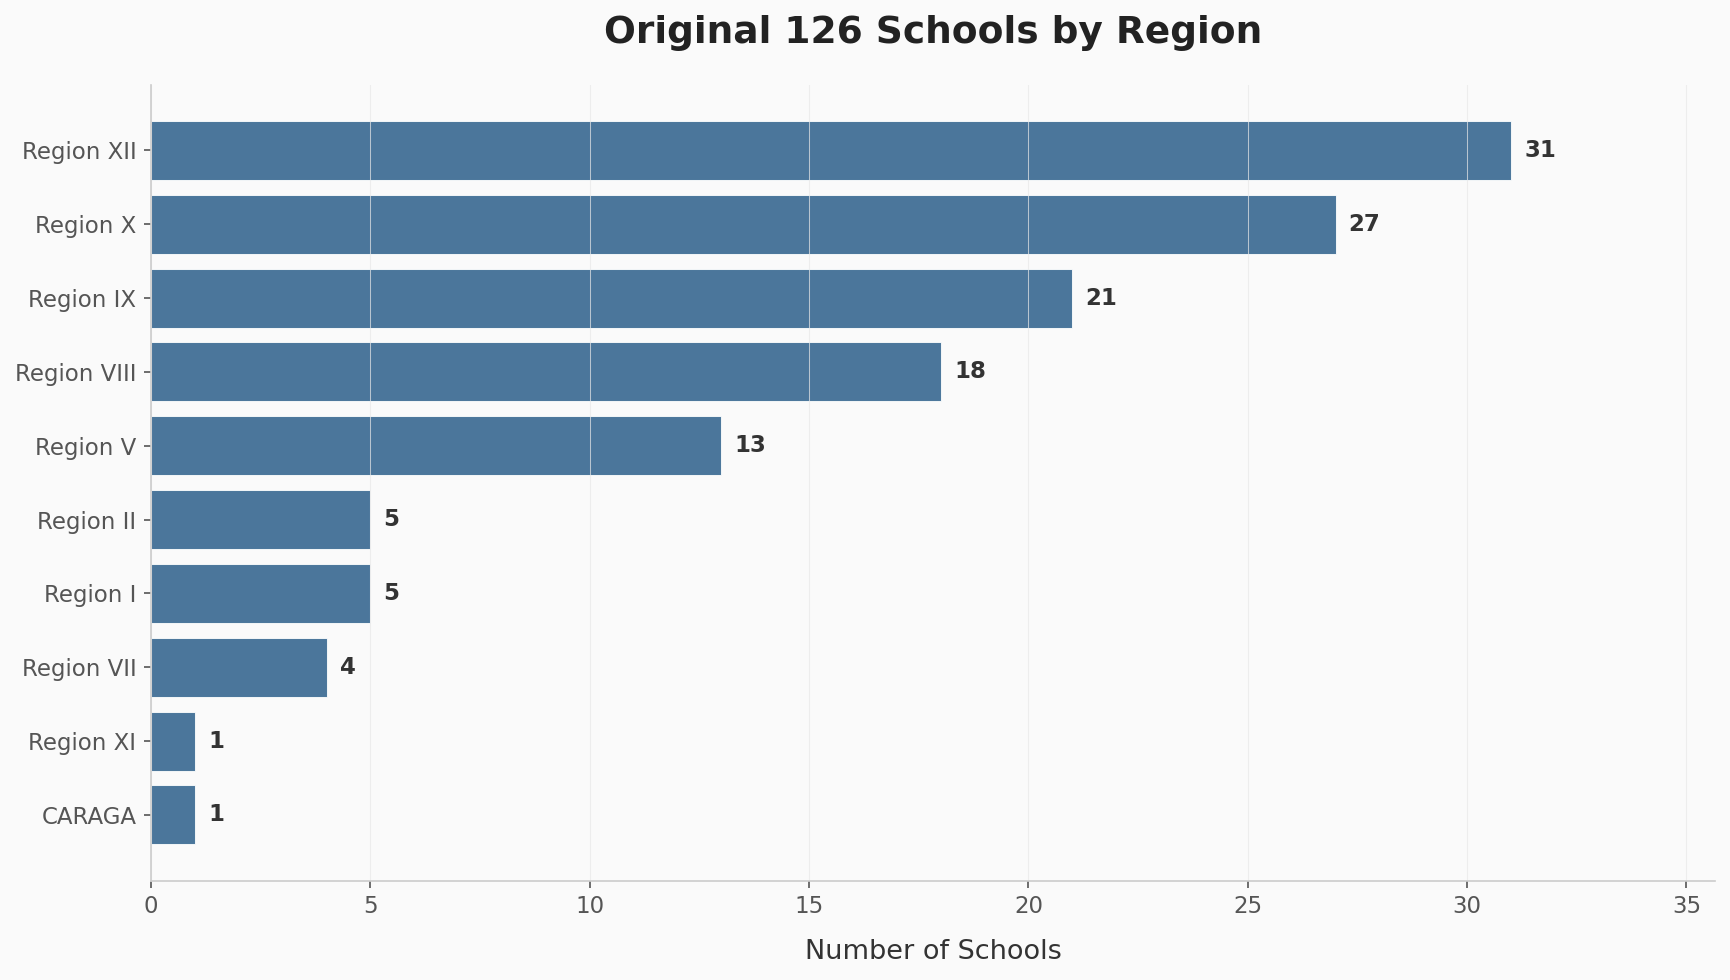

In [3]:
# Chart 1: Original 131 List (126 Unique Schools) by region
# Get region for all 126 unique schools
region_data = []
for sid in all_old_ids:
    # Try metadata first, then Excel sheets
    if sid in meta_lookup.index:
        region_data.append({'School ID': sid, 'Region': meta_lookup.loc[sid, 'Region']})
    else:
        match = excel_included[excel_included['School ID'] == sid]
        if len(match) == 0:
            match = excel_excluded[excel_excluded['School ID'] == sid]
        if len(match) > 0:
            region_data.append({'School ID': sid, 'Region': match.iloc[0]['Region']})

region_df = pd.DataFrame(region_data)
region_counts = region_df['Region'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(region_counts)), region_counts.values,
               color=PRIMARY, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.set_yticks(range(len(region_counts)))
ax.set_yticklabels(region_counts.index, fontsize=11)
ax.set_xlabel('Number of Schools')
ax.set_title('Original 126 Schools by Region', fontsize=18, fontweight='bold')

# Annotate counts
for i, (val, name) in enumerate(zip(region_counts.values, region_counts.index)):
    ax.text(val + 0.3, i, str(val), va='center', fontsize=11, color='#333333', fontweight='bold')

ax.set_xlim(0, region_counts.max() * 1.15)
clean_axes(ax)
ax.grid(axis='y', visible=False)
plt.tight_layout(pad=2.0)
plt.show()


---

## B. Applying the New Method

We re-evaluated all 126 unique schools against the **Learning segment (BoSY 2024-25 → EoSY 2024-25)** priority ranking, which uses the three-pillar ordinal method.

Schools must meet data-quality thresholds to be ranked: sufficient assessed students, stable counts across timepoints, and adequate grade-language group coverage.


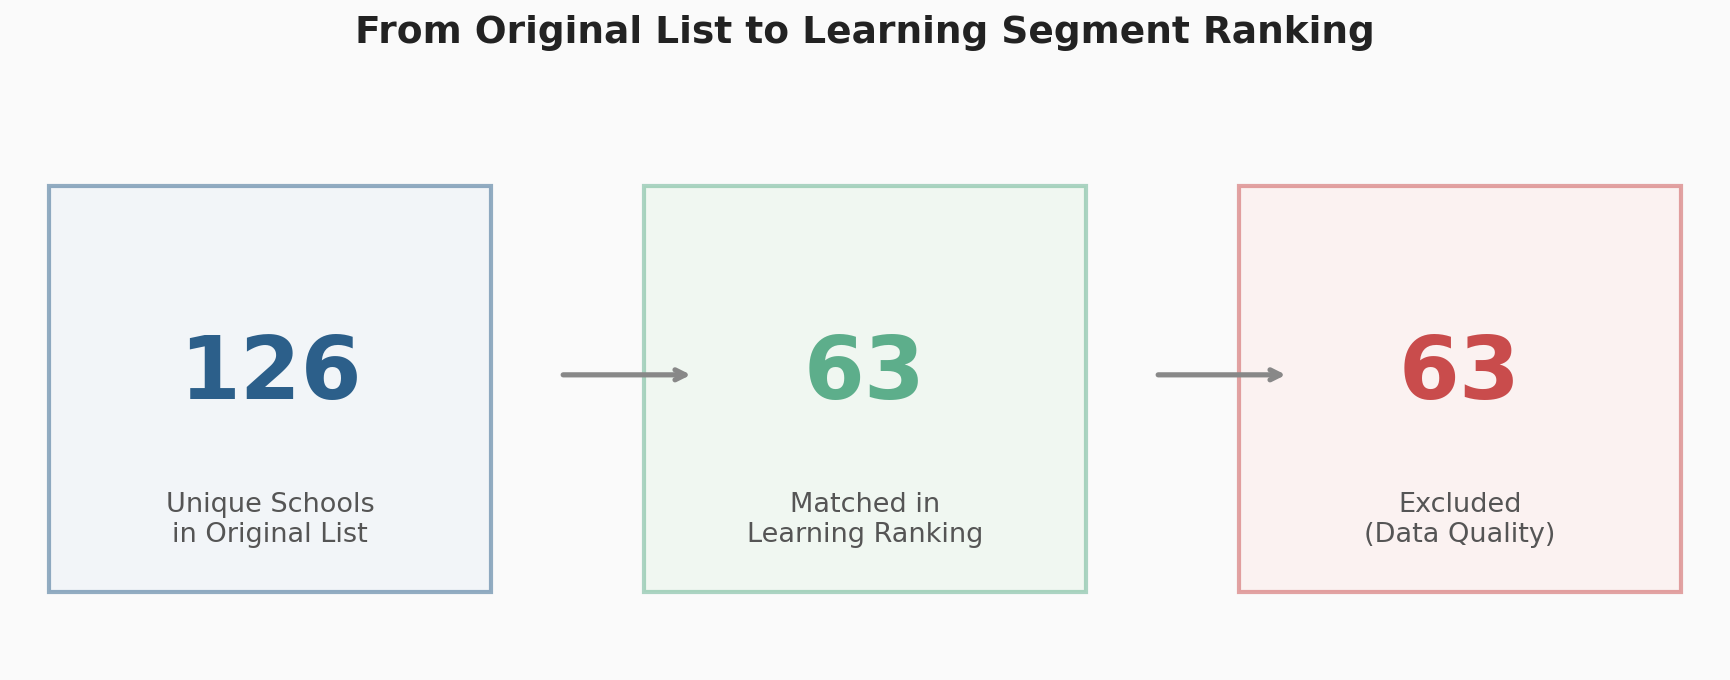

In [4]:
# Chart 2: Funnel / flow diagram
n_total = len(all_old_ids)
n_matched = len(matched_ids)
n_excluded = len(excluded_ids)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis('off')
fig.patch.set_facecolor('#FAFAFA')

# Three boxes connected by arrows
box_style = dict(boxstyle='round,pad=0.6', facecolor='white', edgecolor='#CCCCCC', linewidth=1.5)

# Box 1: Original
ax.text(1.5, 2, f'{n_total}', fontsize=42, fontweight='bold', ha='center', va='center', color=PRIMARY)
ax.text(1.5, 1.0, 'Unique Schools\nin Original List', fontsize=13, ha='center', va='center', color='#555555')
ax.add_patch(plt.Rectangle((0.2, 0.5), 2.6, 2.8, fill=True, facecolor='#EBF2F8',
                             edgecolor=PRIMARY, linewidth=2, alpha=0.5, zorder=0,
                             transform=ax.transData, clip_on=False))

# Arrow 1
ax.annotate('', xy=(4.0, 2), xytext=(3.2, 2),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=2.5))

# Box 2: Matched
ax.text(5.0, 2, f'{n_matched}', fontsize=42, fontweight='bold', ha='center', va='center', color=ACCENT)
ax.text(5.0, 1.0, 'Matched in\nLearning Ranking', fontsize=13, ha='center', va='center', color='#555555')
ax.add_patch(plt.Rectangle((3.7, 0.5), 2.6, 2.8, fill=True, facecolor='#E8F5E9',
                             edgecolor=ACCENT, linewidth=2, alpha=0.5, zorder=0))

# Arrow 2
ax.annotate('', xy=(7.5, 2), xytext=(6.7, 2),
            arrowprops=dict(arrowstyle='->', color='#888888', lw=2.5))

# Box 3: Excluded
ax.text(8.5, 2, f'{n_excluded}', fontsize=42, fontweight='bold', ha='center', va='center', color=WARNING)
ax.text(8.5, 1.0, 'Excluded\n(Data Quality)', fontsize=13, ha='center', va='center', color='#555555')
ax.add_patch(plt.Rectangle((7.2, 0.5), 2.6, 2.8, fill=True, facecolor='#FDECEA',
                             edgecolor=WARNING, linewidth=2, alpha=0.5, zorder=0))

ax.set_title('From Original List to Learning Segment Ranking', fontsize=18, fontweight='bold',
             color='#222222', pad=20)
plt.tight_layout(pad=2.0)
plt.show()


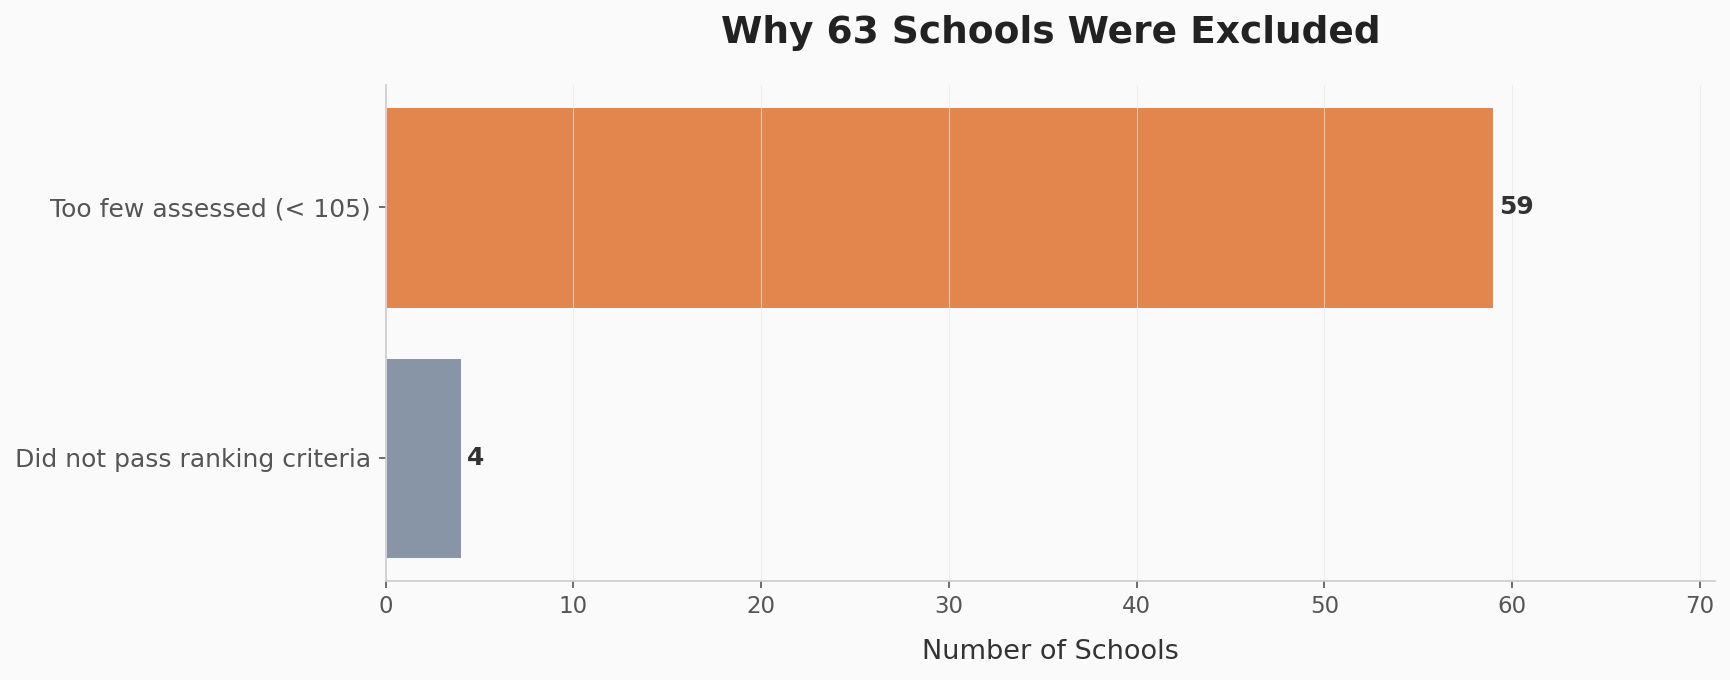

In [5]:
# Chart 3: Exclusion reasons — horizontal bar
reason_counts = exclusion_df['reason'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(12, 5))
colors_exc = [SECONDARY if 'few' in r.lower() else WARNING if 'unstable' in r.lower()
              else NEUTRAL for r in reason_counts.index]
bars = ax.barh(range(len(reason_counts)), reason_counts.values,
               color=colors_exc, edgecolor='white', linewidth=0.5, alpha=0.9)

ax.set_yticks(range(len(reason_counts)))
ax.set_yticklabels(reason_counts.index, fontsize=12)
ax.set_xlabel('Number of Schools')
ax.set_title(f'Why {n_excluded} Schools Were Excluded', fontsize=18, fontweight='bold')

for i, val in enumerate(reason_counts.values):
    ax.text(val + 0.3, i, str(val), va='center', fontsize=12, fontweight='bold', color='#333333')

ax.set_xlim(0, reason_counts.max() * 1.2)
clean_axes(ax)
ax.grid(axis='y', visible=False)
plt.tight_layout(pad=2.0)
plt.show()


**Key takeaway:** Most exclusions stem from small school size — too few assessed students to produce reliable ordinal statistics. This is a data-quality safeguard, not a judgment on school performance.


In [6]:
from IPython.display import Markdown, display
display(Markdown(f"""---

## C. Where Do Our Schools Stand?

The **{len(matched_ids)}** matched schools now have three-pillar scores. Let's examine where they fall in the national distribution.
"""))


---

## C. Where Do Our Schools Stand?

The **63** matched schools now have three-pillar scores. Let's examine where they fall in the national distribution.


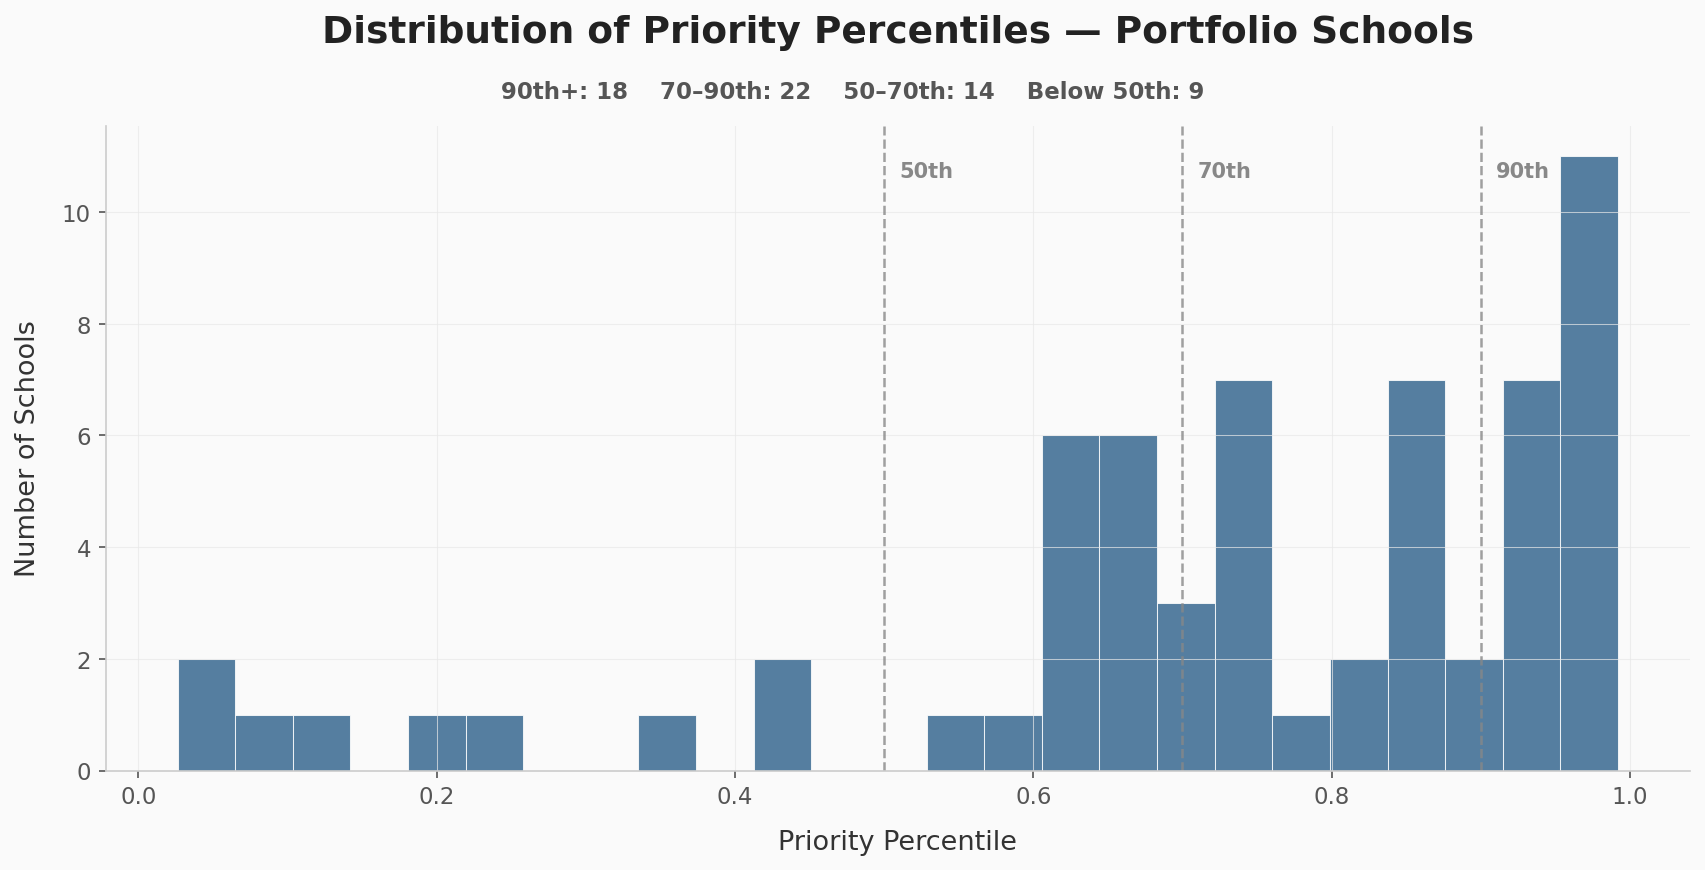

In [7]:
# Chart 4: Priority percentile distribution
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(portfolio['priority_pctile'], bins=25, color=PRIMARY, alpha=0.8,
        edgecolor='white', linewidth=0.5)

# Band lines
for pct, label, clr in [(0.5, '50th', '#888888'), (0.7, '70th', '#888888'), (0.9, '90th', '#888888')]:
    ax.axvline(pct, linestyle='--', color=clr, linewidth=1.2, alpha=0.8)
    ax.text(pct + 0.01, ax.get_ylim()[1] * 0.92, label, fontsize=10, color=clr, fontweight='bold')

# Annotate band counts — place below title as subtitle
band_counts = portfolio['priority_band'].value_counts()
legend_text = '    '.join([f"{b}: {band_counts.get(b, 0)}" for b in BAND_ORDER])
ax.set_title('Distribution of Priority Percentiles — Portfolio Schools\n',
             fontsize=18, fontweight='bold')
fig.text(0.5, 0.91, legend_text, ha='center', fontsize=11,
         color='#555555', fontweight='bold')

ax.set_xlabel('Priority Percentile')
ax.set_ylabel('Number of Schools')
clean_axes(ax)
plt.tight_layout(pad=2.5)
plt.subplots_adjust(top=0.88)
plt.show()


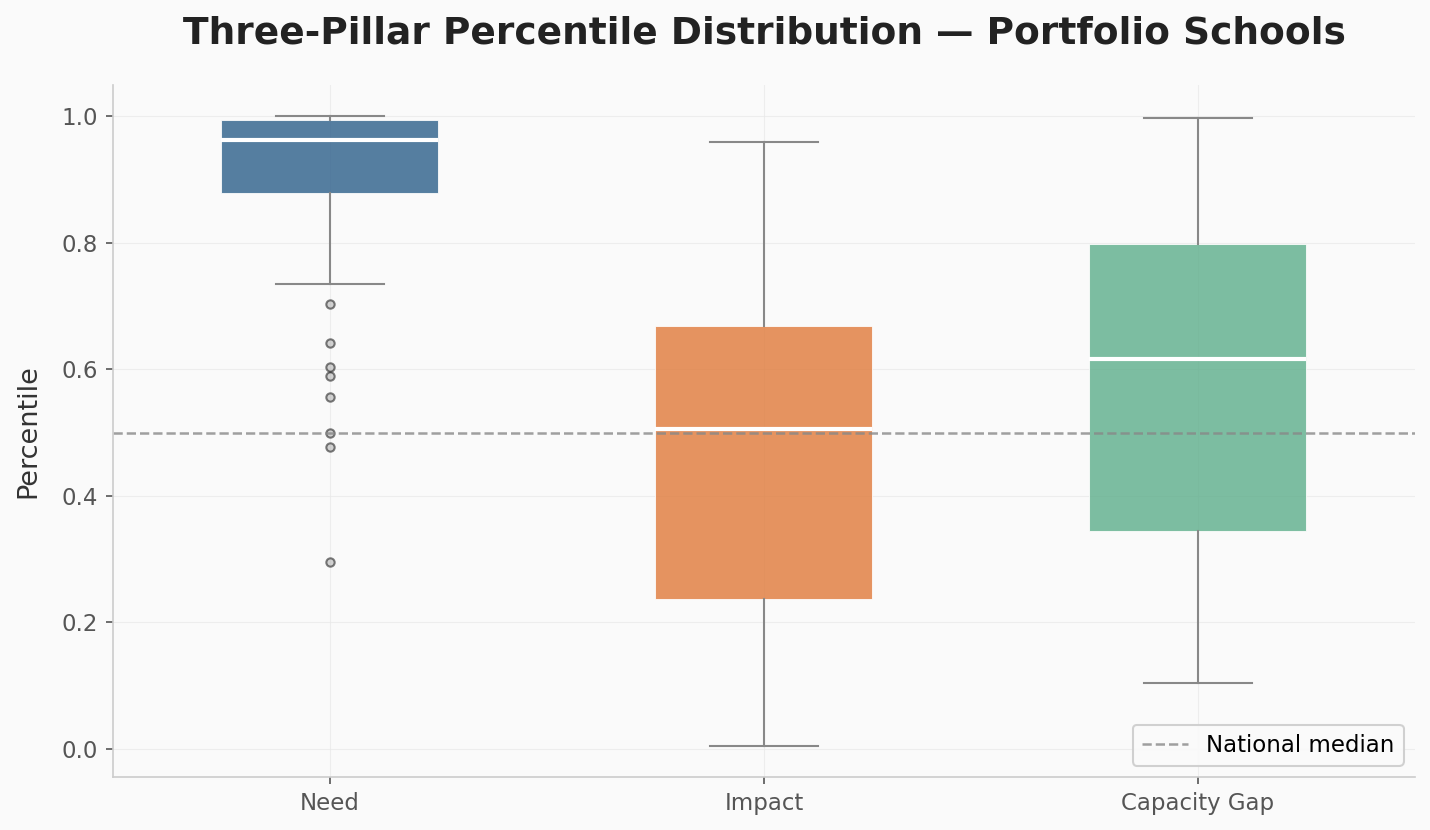

In [8]:
# Chart 5: Three-pillar boxplots
fig, ax = plt.subplots(figsize=(10, 6))

pillar_data = [portfolio['need_pctile'], portfolio['impact_pctile'], portfolio['capacity_gap_pctile']]
pillar_names = ['Need', 'Impact', 'Capacity Gap']
pillar_colors = [PRIMARY, SECONDARY, ACCENT]

bp = ax.boxplot(pillar_data, labels=pillar_names, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#888888'), capprops=dict(color='#888888'),
                flierprops=dict(marker='o', markerfacecolor='#AAAAAA', markersize=4, alpha=0.5))

for patch, color in zip(bp['boxes'], pillar_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor('white')
    patch.set_linewidth(0.5)

ax.axhline(0.5, linestyle='--', color='#888888', linewidth=1.2, alpha=0.8, label='National median')
ax.set_ylabel('Percentile')
ax.set_title('Three-Pillar Percentile Distribution — Portfolio Schools', fontsize=18, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
clean_axes(ax)
plt.tight_layout(pad=2.0)
plt.show()


The portfolio schools show **high Need** (mostly above the 50th percentile nationally) but **moderate Impact and Capacity Gap** scores — indicating that while these schools serve struggling learners, the measured learning gains and resource gaps vary widely.


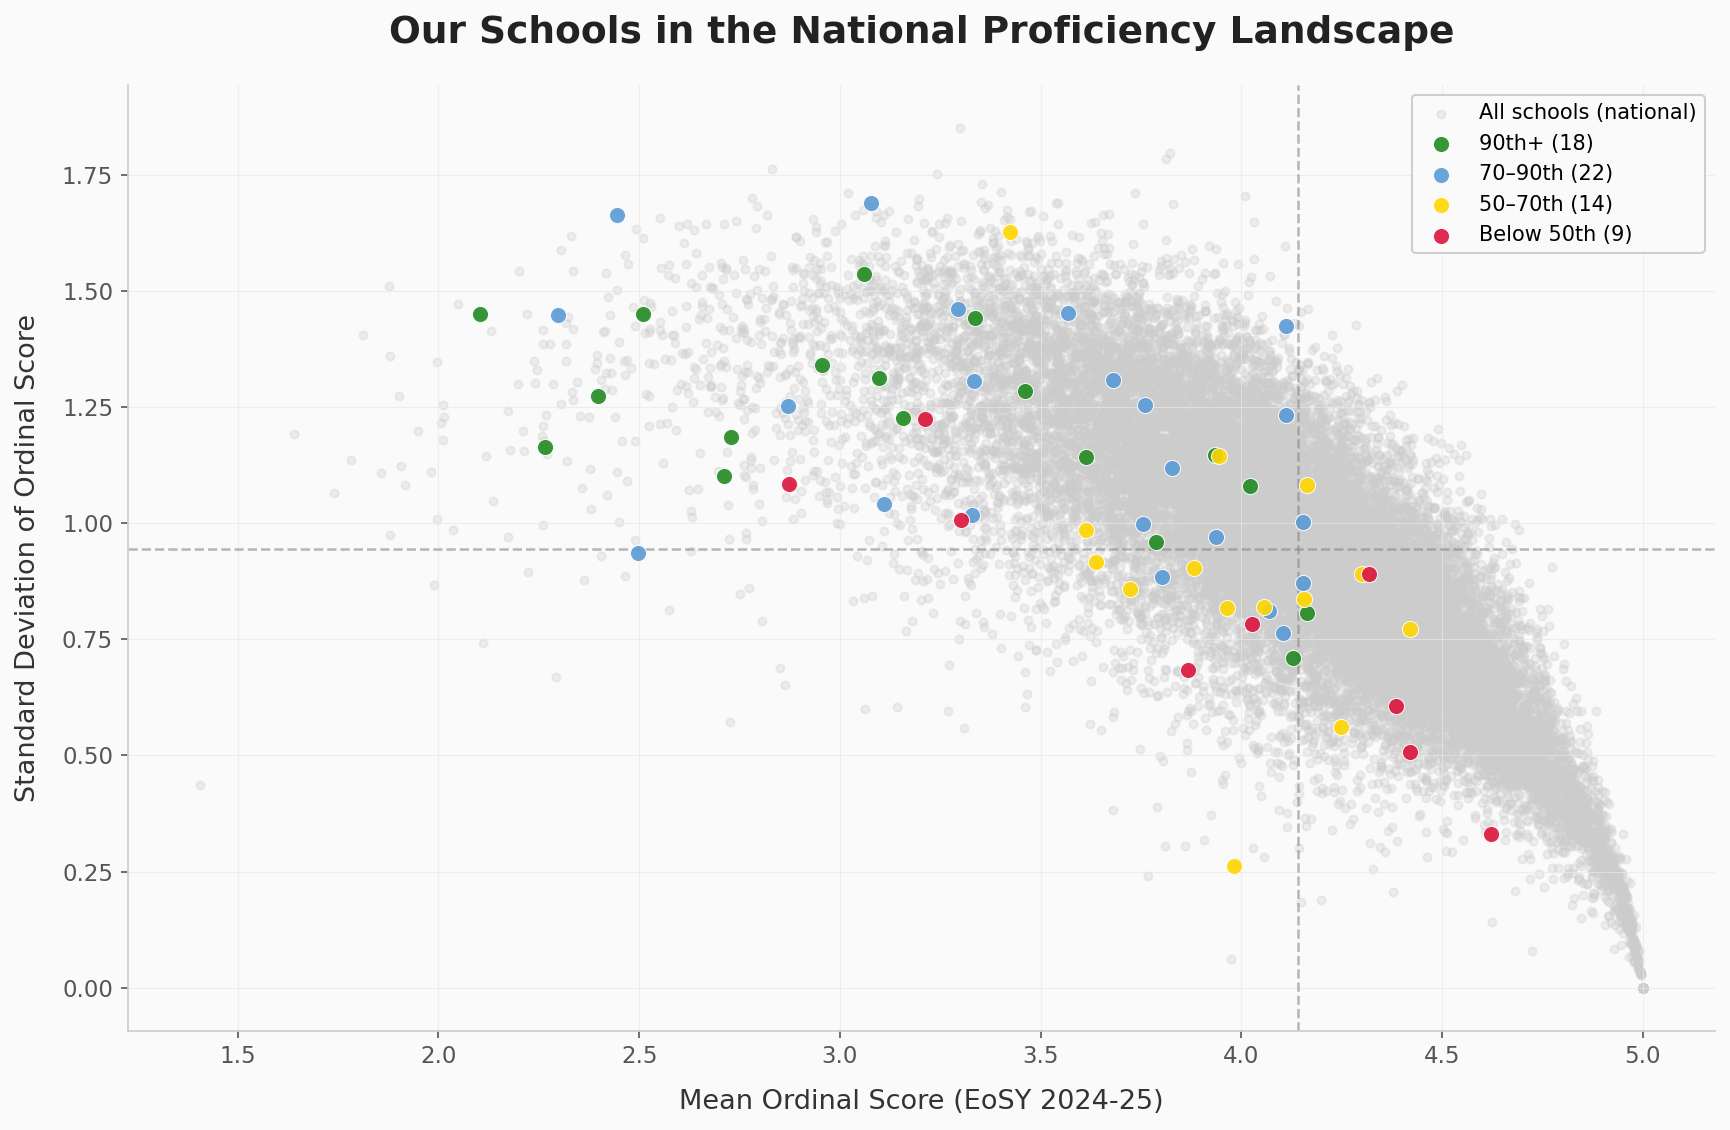

In [9]:
# Chart 5b: National proficiency landscape — mean_end vs sd_end
fig, ax = plt.subplots(figsize=(12, 8))

# All national schools (background)
ax.scatter(priority['mean_end'], priority['sd_end'],
           c='#CCCCCC', alpha=0.3, s=15, label='All schools (national)', zorder=1)

# Portfolio schools colored by band
for band in BAND_ORDER:
    subset = portfolio[portfolio['priority_band'] == band]
    ax.scatter(subset['mean_end'], subset['sd_end'],
               c=BAND_COLORS[band], alpha=0.9, s=60, edgecolors='white', linewidth=0.5,
               label=f'{band} ({len(subset)})', zorder=3)

ax.set_xlabel('Mean Ordinal Score (EoSY 2024-25)')
ax.set_ylabel('Standard Deviation of Ordinal Score')
ax.set_title('Our Schools in the National Proficiency Landscape', fontsize=18, fontweight='bold')

# Reference lines at national medians
ax.axvline(priority['mean_end'].median(), linestyle='--', color='#888888', linewidth=1.2, alpha=0.6)
ax.axhline(priority['sd_end'].median(), linestyle='--', color='#888888', linewidth=1.2, alpha=0.6)

ax.legend(loc='upper right', framealpha=0.95, edgecolor='#CCCCCC', fontsize=10)
clean_axes(ax)
plt.tight_layout(pad=2.0)
plt.show()


**Why does dispersion matter?** Two schools can have the same average score but very different student distributions. A school with high SD has a wider spread — some students performing well, others far behind. The three-pillar method captures this nuance; the old PCA approach did not.


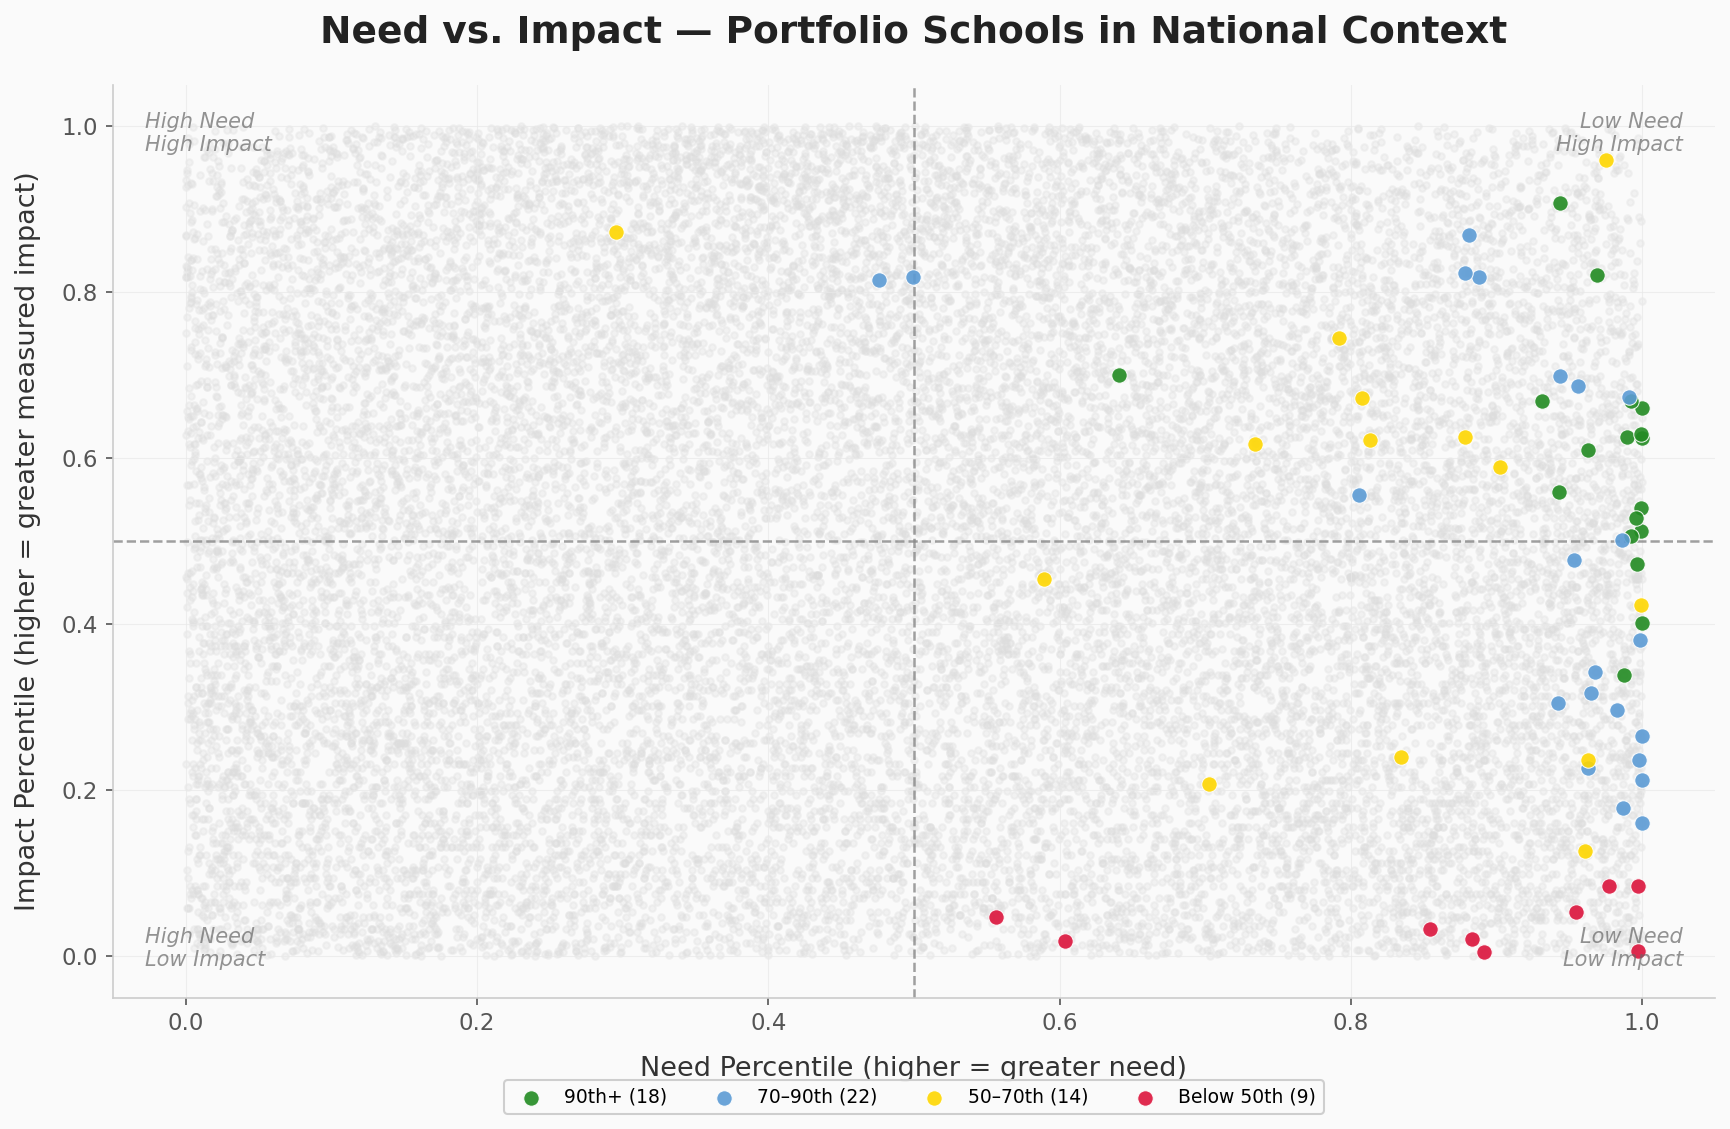

In [10]:
# Chart 6: Need vs Impact scatter
fig, ax = plt.subplots(figsize=(12, 8))

# National background
ax.scatter(priority['need_pctile'], priority['impact_pctile'],
           c='#DDDDDD', alpha=0.3, s=10, zorder=1)

# Portfolio schools
for band in BAND_ORDER:
    subset = portfolio[portfolio['priority_band'] == band]
    ax.scatter(subset['need_pctile'], subset['impact_pctile'],
               c=BAND_COLORS[band], alpha=0.9, s=55, edgecolors='white', linewidth=0.5,
               label=f'{band} ({len(subset)})', zorder=3)

ax.axhline(0.5, linestyle='--', color='#888888', linewidth=1.2, alpha=0.8)
ax.axvline(0.5, linestyle='--', color='#888888', linewidth=1.2, alpha=0.8)

# Quadrant labels
ax.text(0.02, 0.97, 'High Need\nHigh Impact', transform=ax.transAxes, ha='left', va='top',
        fontsize=10, color='#666666', fontstyle='italic', alpha=0.7)
ax.text(0.98, 0.97, 'Low Need\nHigh Impact', transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='#666666', fontstyle='italic', alpha=0.7)
ax.text(0.02, 0.03, 'High Need\nLow Impact', transform=ax.transAxes, ha='left', va='bottom',
        fontsize=10, color='#666666', fontstyle='italic', alpha=0.7)
ax.text(0.98, 0.03, 'Low Need\nLow Impact', transform=ax.transAxes, ha='right', va='bottom',
        fontsize=10, color='#666666', fontstyle='italic', alpha=0.7)

ax.set_xlabel('Need Percentile (higher = greater need)')
ax.set_ylabel('Impact Percentile (higher = greater measured impact)')
ax.set_title('Need vs. Impact — Portfolio Schools in National Context', fontsize=18, fontweight='bold')
ax.legend(loc='upper center', framealpha=0.95, edgecolor='#CCCCCC', ncol=5, fontsize=9,
        bbox_to_anchor=(0.5, -0.08))
clean_axes(ax)
plt.tight_layout(pad=2.0)
plt.show()


---

## D. A Closer Look at Individual Schools

Which portfolio schools rank **highest** and **lowest** under the new method?


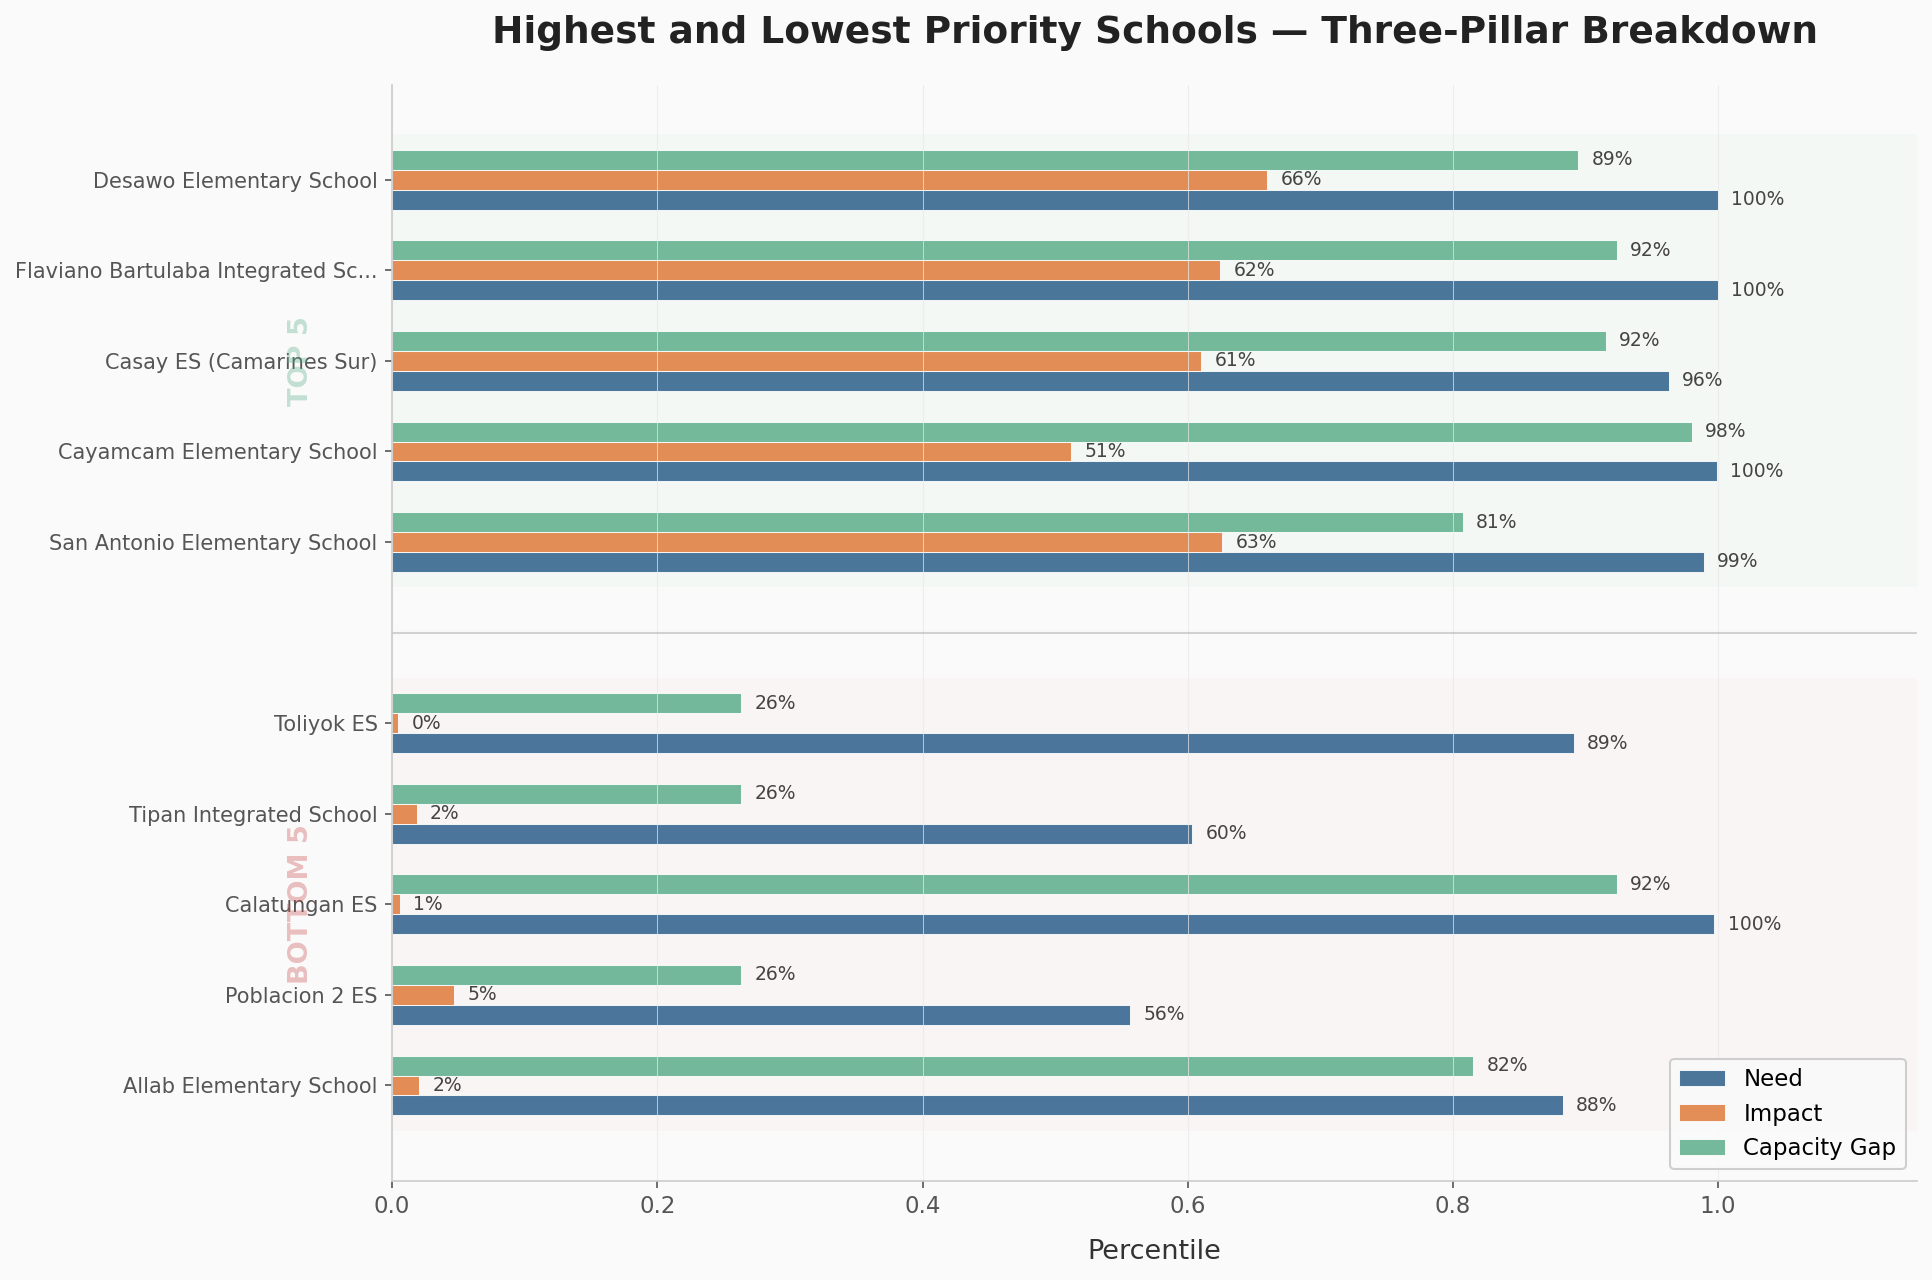

In [11]:
# Chart 7: Top 5 and Bottom 5 — grouped horizontal bar
top5 = portfolio.nlargest(5, 'priority_pctile').sort_values('priority_pctile')
bot5 = portfolio.nsmallest(5, 'priority_pctile').sort_values('priority_pctile', ascending=False)

# Combine with a gap
spotlight = pd.concat([bot5, top5])
n = len(spotlight)
positions = list(range(5)) + list(range(6, 11))  # gap at position 5

labels = []
for _, row in spotlight.iterrows():
    name = row['school_name']
    if len(name) > 35:
        name = name[:32] + '...'
    labels.append(name)

fig, ax = plt.subplots(figsize=(14, 9))

# Background shading
ax.axhspan(-0.5, 4.5, facecolor='#FDECEA', alpha=0.3, zorder=0)  # bottom 5 = red
ax.axhspan(5.5, 10.5, facecolor='#E8F5E9', alpha=0.3, zorder=0)  # top 5 = green

bar_height = 0.22
pillar_info = [
    ('need_pctile', 'Need', PRIMARY),
    ('impact_pctile', 'Impact', SECONDARY),
    ('capacity_gap_pctile', 'Capacity Gap', ACCENT),
]

for j, (col, label, color) in enumerate(pillar_info):
    offsets = [p + (j - 1) * bar_height for p in positions]
    values = spotlight[col].values
    ax.barh(offsets, values, height=bar_height, color=color, alpha=0.85,
            edgecolor='white', linewidth=0.5, label=label)
    for pos, val in zip(offsets, values):
        ax.text(val + 0.01, pos, f'{val:.0%}', va='center', fontsize=9, color='#444444')

ax.set_yticks(positions)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Percentile')
ax.set_title('Highest and Lowest Priority Schools — Three-Pillar Breakdown',
             fontsize=18, fontweight='bold')

# Divider line
ax.axhline(5, color='#AAAAAA', linewidth=1, linestyle='-', alpha=0.5)

# Group labels — place in background shading using data coords
ax.text(-0.06, 8, 'TOP 5', ha='center', va='center', fontsize=13, fontweight='bold',
        color=ACCENT, alpha=0.35, rotation=90, transform=ax.get_yaxis_transform())
ax.text(-0.06, 2, 'BOTTOM 5', ha='center', va='center', fontsize=13, fontweight='bold',
        color=WARNING, alpha=0.35, rotation=90, transform=ax.get_yaxis_transform())

ax.legend(loc='lower right', framealpha=0.95, edgecolor='#CCCCCC')
ax.set_xlim(0, 1.15)
clean_axes(ax)
ax.grid(axis='y', visible=False)
plt.tight_layout(pad=2.0)
plt.subplots_adjust(left=0.25)
plt.show()


---

## E. What About the Excluded Schools?

These schools lacked sufficient data for the Learning segment ranking. But where we have ordinal scores, we can still see how they compare.


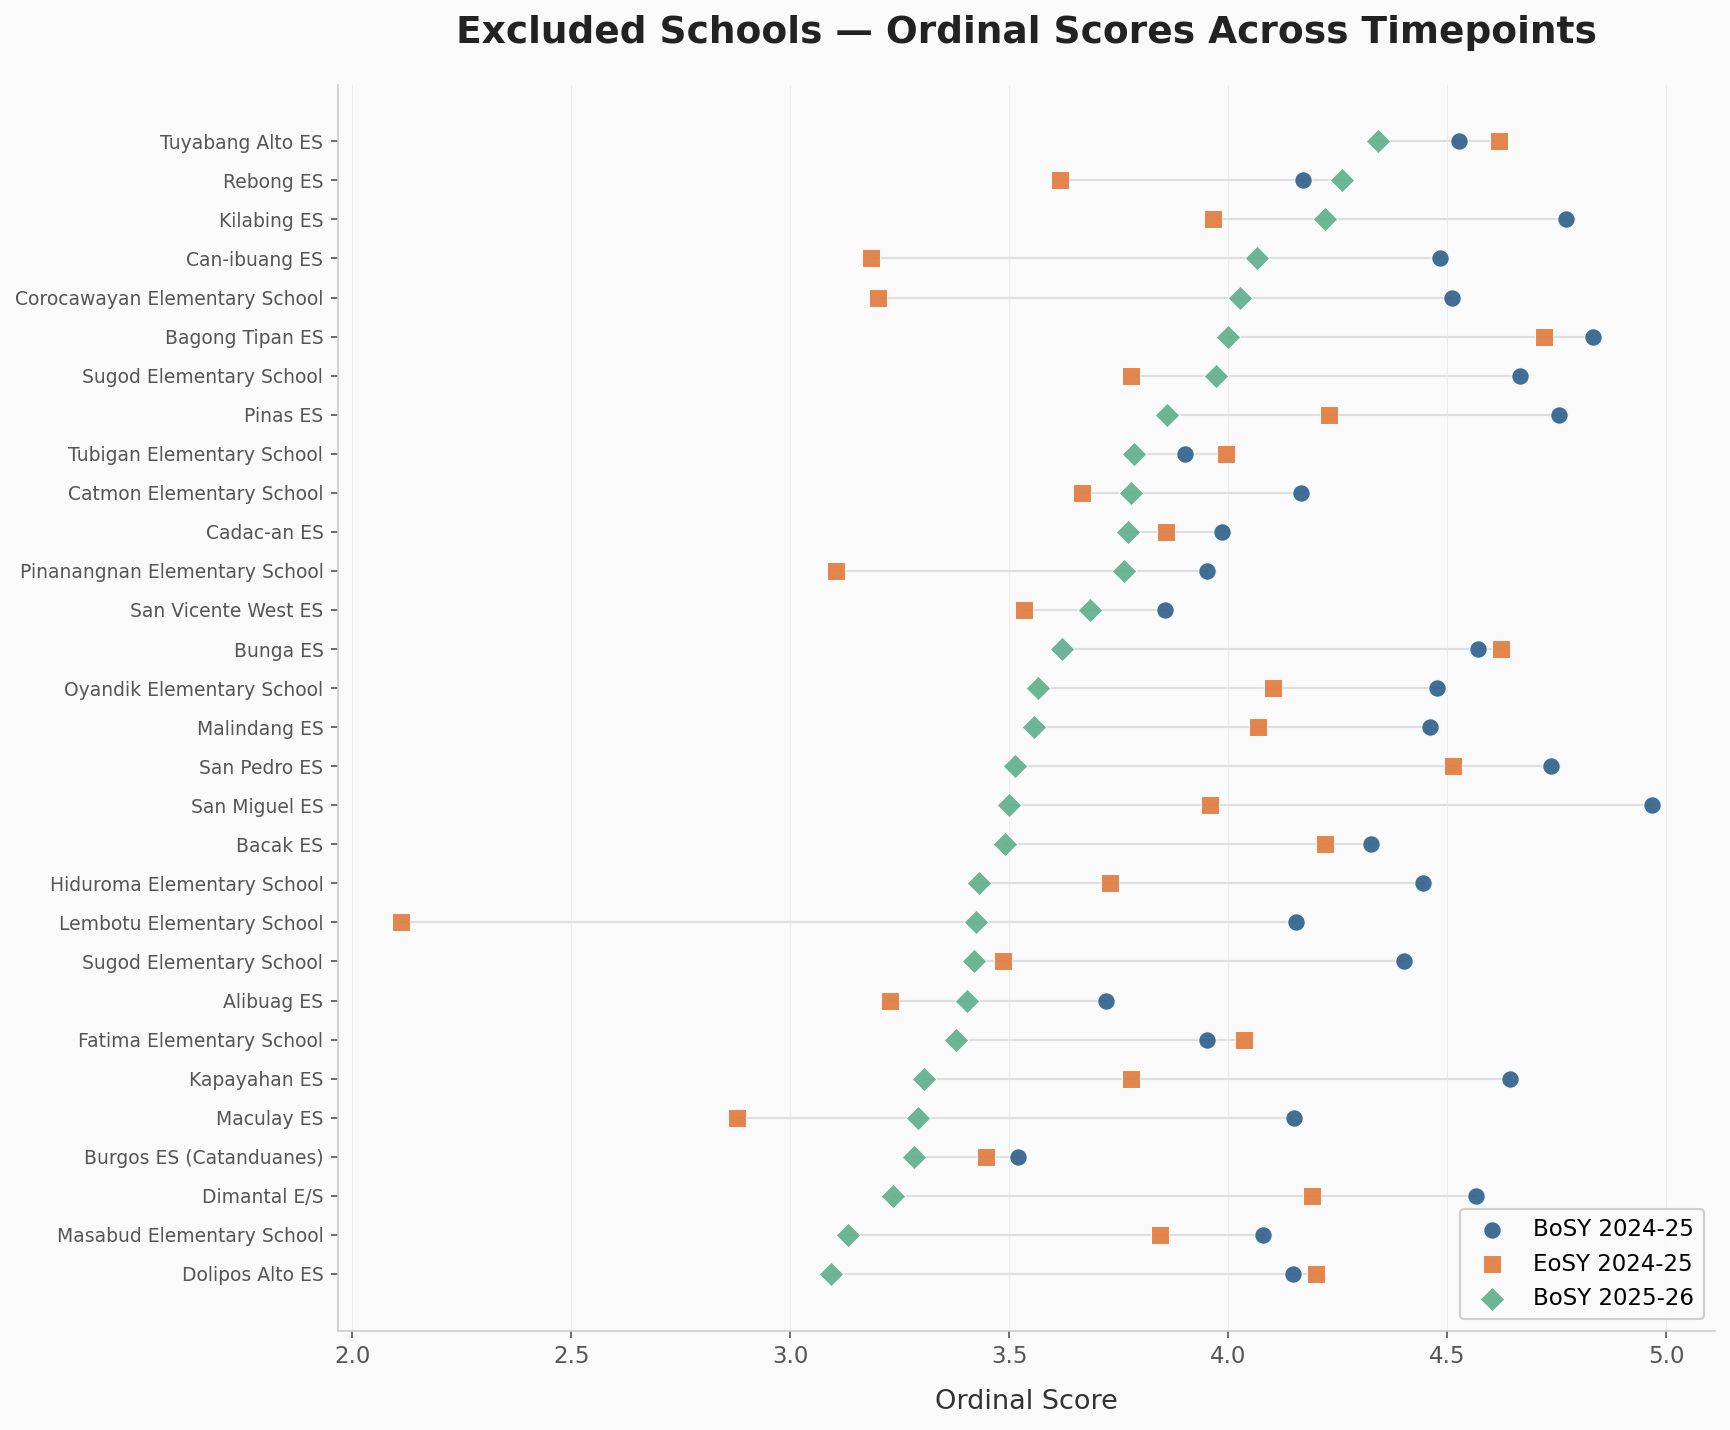

In [12]:
# Chart 8: Excluded schools — ordinal scores by timepoint
# Join using School ID, display names on y-axis
exc_ordinal = ordinal[ordinal['School ID'].isin(excluded_ids)].copy()
exc_ordinal = exc_ordinal[exc_ordinal['valid'] == True]

# Pivot to get scores by timepoint
exc_pivot = exc_ordinal.pivot_table(index='School ID', columns='timepoint_label',
                                     values='ordinal_overall', aggfunc='first')

# Sort by BoSY 2025-26 score (or whatever is available)
sort_col = 'BoSY 2025-26' if 'BoSY 2025-26' in exc_pivot.columns else exc_pivot.columns[0]
exc_pivot = exc_pivot.sort_values(sort_col, ascending=True, na_position='first')

# Limit to 30 schools
exc_pivot = exc_pivot.tail(30)

# Get display names
name_map = metadata.set_index('School ID')['School Name'].to_dict()
# Fill from Excel for missing
for sid in excluded_ids:
    if sid not in name_map:
        match = excel_excluded[excel_excluded['School ID'] == sid]
        if len(match) > 0:
            name_map[sid] = match.iloc[0]['School Name']
        else:
            match = excel_included[excel_included['School ID'] == sid]
            if len(match) > 0:
                name_map[sid] = match.iloc[0]['School Name']

display_names = []
for sid in exc_pivot.index:
    name = name_map.get(sid, str(sid))
    if isinstance(name, str) and len(name) > 35:
        name = name[:32] + '...'
    display_names.append(name)

fig, ax = plt.subplots(figsize=(12, 10))

timepoint_styles = {
    'BoSY 2024-25': (PRIMARY, 'o', 'BoSY 2024-25'),
    'EoSY 2024-25': (SECONDARY, 's', 'EoSY 2024-25'),
    'BoSY 2025-26': (ACCENT, 'D', 'BoSY 2025-26'),
}

y_positions = range(len(exc_pivot))
for tp, (color, marker, label) in timepoint_styles.items():
    if tp in exc_pivot.columns:
        vals = exc_pivot[tp].values
        mask = ~np.isnan(vals)
        y_pos = np.array(list(y_positions))
        ax.scatter(vals[mask], y_pos[mask], c=color, marker=marker, s=70,
                   edgecolors='white', linewidth=0.5, alpha=0.9, label=label, zorder=3)

# Connect dots for each school
for i, sid in enumerate(exc_pivot.index):
    scores = [exc_pivot.loc[sid].get(tp, np.nan) for tp in timepoint_styles]
    valid_scores = [s for s in scores if not np.isnan(s)]
    if len(valid_scores) > 1:
        ax.plot([min(valid_scores), max(valid_scores)], [i, i],
                color='#CCCCCC', linewidth=1, alpha=0.6, zorder=1)

ax.set_yticks(list(y_positions))
ax.set_yticklabels(display_names, fontsize=9)
ax.set_xlabel('Ordinal Score')
ax.set_title('Excluded Schools — Ordinal Scores Across Timepoints',
             fontsize=18, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.95, edgecolor='#CCCCCC')
clean_axes(ax)
ax.grid(axis='y', visible=False)
plt.tight_layout(pad=2.0)
plt.show()


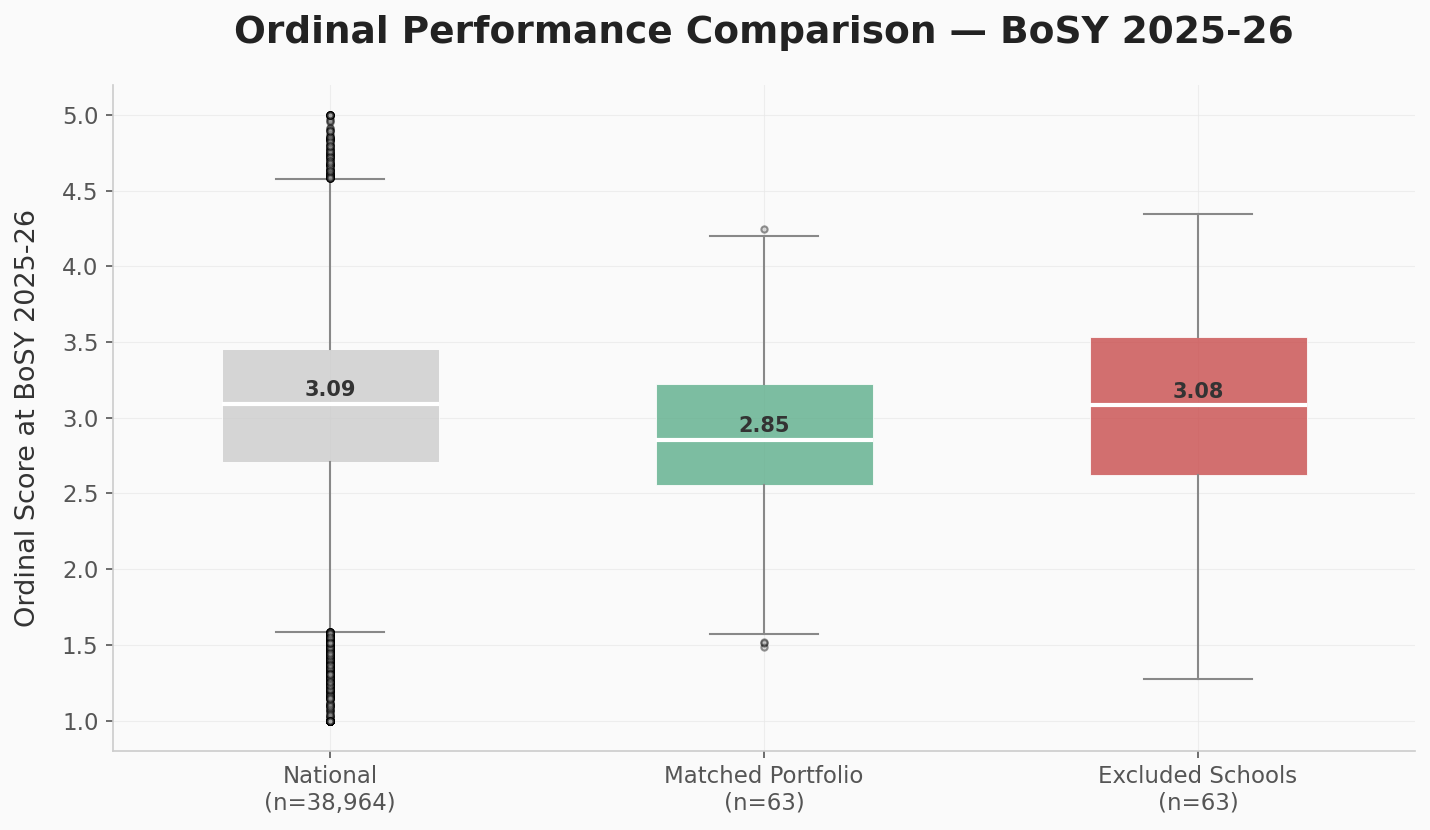

In [13]:
# Chart 9: BoSY 2025-26 ordinal mean — matched vs excluded vs national
bosy26 = ordinal[(ordinal['timepoint_label'] == 'BoSY 2025-26') & (ordinal['valid'] == True)].copy()
bosy26_national = bosy26[bosy26['School ID'] != -1]  # exclude the national row

matched_scores = bosy26_national[bosy26_national['School ID'].isin(matched_ids)]['ordinal_overall']
excluded_scores = bosy26_national[bosy26_national['School ID'].isin(excluded_ids)]['ordinal_overall']
national_scores = bosy26_national['ordinal_overall']

fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = [national_scores.dropna(), matched_scores.dropna(), excluded_scores.dropna()]
labels_bp = [f'National\n(n={len(data_to_plot[0]):,})',
             f'Matched Portfolio\n(n={len(data_to_plot[1])})',
             f'Excluded Schools\n(n={len(data_to_plot[2])})']
colors_bp = ['#CCCCCC', ACCENT, WARNING]

bp = ax.boxplot(data_to_plot, labels=labels_bp, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2),
                whiskerprops=dict(color='#888888'), capprops=dict(color='#888888'),
                flierprops=dict(marker='o', markerfacecolor='#AAAAAA', markersize=3, alpha=0.4))

for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
    patch.set_edgecolor('white')
    patch.set_linewidth(0.5)

ax.set_ylabel('Ordinal Score at BoSY 2025-26')
ax.set_title('Ordinal Performance Comparison — BoSY 2025-26', fontsize=18, fontweight='bold')

# Annotate medians
for i, data in enumerate(data_to_plot, 1):
    med = data.median()
    ax.text(i, med + 0.05, f'{med:.2f}', ha='center', fontsize=10, fontweight='bold', color='#333333')

clean_axes(ax)
plt.tight_layout(pad=2.0)
plt.show()


The excluded schools tend to have **similar or even lower ordinal scores** than the matched portfolio — they are indeed schools in need, but their data is too limited for reliable ranking under the current method.


---

## F. A System That Improves With Data

As more assessment cycles complete, more schools will cross the data-quality threshold and enter the ranking. The new method is designed to **get better over time**.


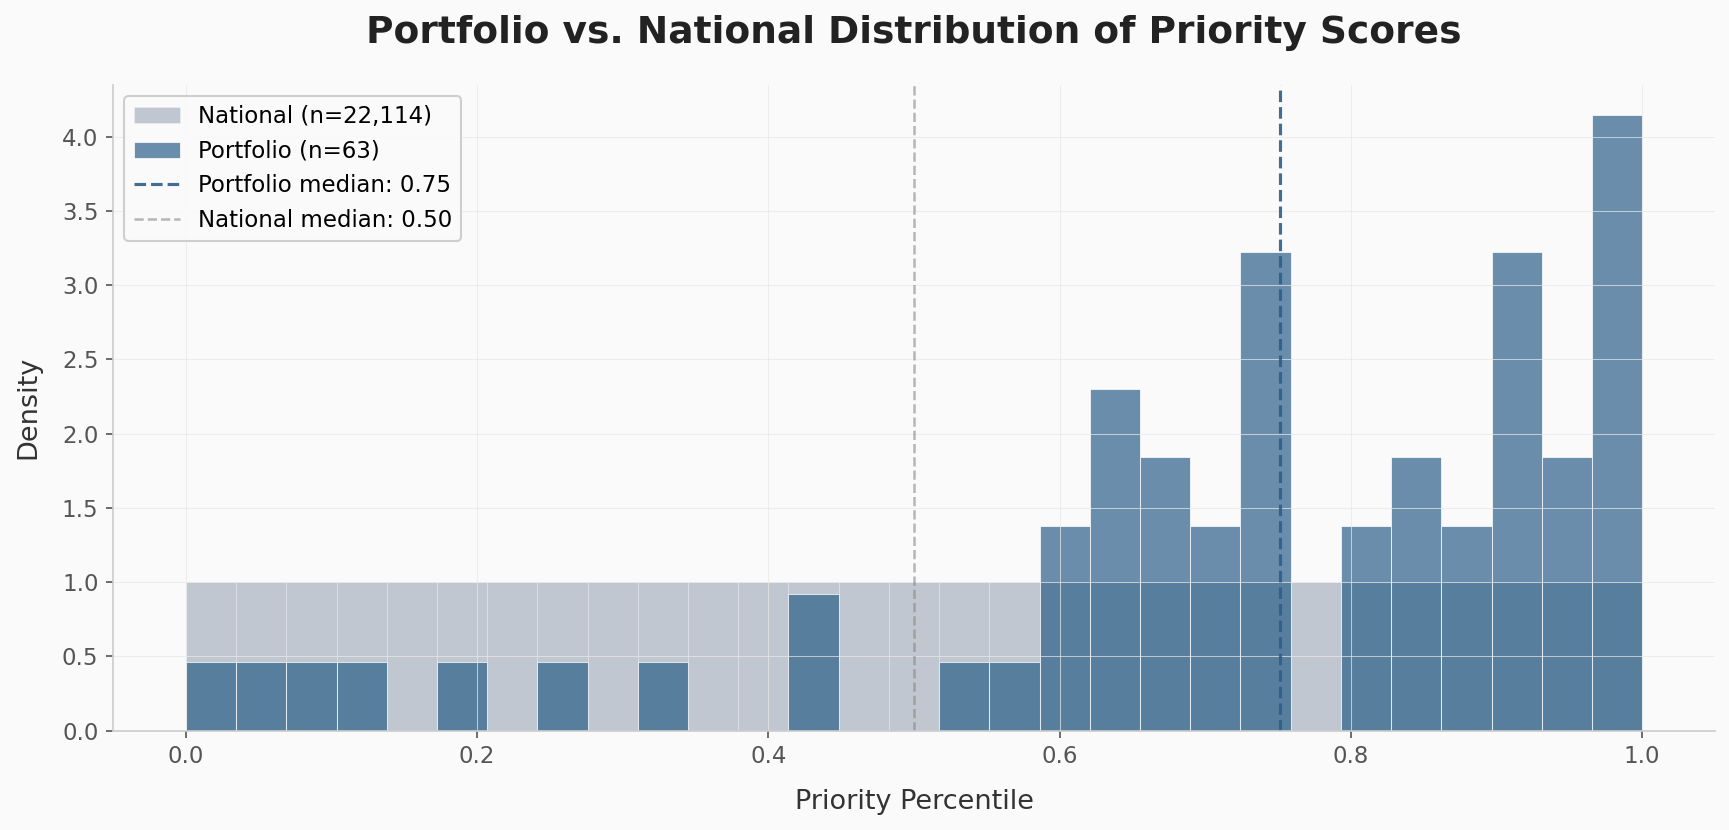

In [14]:
# Chart 10: Portfolio vs national priority percentile distribution
fig, ax = plt.subplots(figsize=(12, 6))

bins = np.linspace(0, 1, 30)

ax.hist(priority['priority_pctile'], bins=bins, alpha=0.45, color=NEUTRAL,
        edgecolor='white', linewidth=0.3, density=True, label=f'National (n={len(priority):,})')
ax.hist(portfolio['priority_pctile'], bins=bins, alpha=0.7, color=PRIMARY,
        edgecolor='white', linewidth=0.5, density=True, label=f'Portfolio (n={len(portfolio)})')

ax.axvline(portfolio['priority_pctile'].median(), linestyle='--', color=PRIMARY,
           linewidth=1.5, alpha=0.9, label=f'Portfolio median: {portfolio["priority_pctile"].median():.2f}')
ax.axvline(0.5, linestyle='--', color='#888888', linewidth=1.2, alpha=0.6, label='National median: 0.50')

ax.set_xlabel('Priority Percentile')
ax.set_ylabel('Density')
ax.set_title('Portfolio vs. National Distribution of Priority Scores',
             fontsize=18, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.95, edgecolor='#CCCCCC')
clean_axes(ax)
plt.tight_layout(pad=2.0)
plt.show()


---

### Key Takeaways

1. **The original PCA list selected schools with genuine need** — most portfolio schools rank above the national median on the Need pillar.

2. **The new three-pillar method adds nuance** — separating Need, Impact, and Capacity Gap reveals that high need does not always coincide with high impact or large resource gaps.

3. **Data quality is a feature, not a bug** — excluded schools are not forgotten; they will be included as their assessment data grows more robust.

4. **Mean alone is insufficient** — the scatter of mean vs. standard deviation shows that schools with similar averages can have very different student distributions, which the ordinal method captures.

---

*Analysis conducted using the three-pillar ordinal priority ranking method (Learning segment: BoSY → EoSY 2024-25). Schools must pass strict validation to be ranked.*
